# Value at Risk: Modular Framework
This notebook builds a modular VaR evaluation pipeline from scratch, allowing testing of different parameters (like rolling windows and alpha levels).

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

## 1. Fetching Data

In [2]:
def fetch_data(ticker, start_date="2010-01-01", end_date=None):
    """Fetches historical price data from Yahoo Finance."""
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        try:
            df.columns = df.columns.droplevel(1)
        except:
            pass
            
    if 'Adj Close' in df.columns:
        prices = df['Adj Close']
    else:
        prices = df['Close']
    return pd.DataFrame({'price': prices})

ticker = "^GSPC" # Example: S&P 500
df_raw = fetch_data(ticker)
df_raw.head()

Fetching data for ^GSPC...


,price
Date,
2010-01-04,1132.989990
2010-01-05,1136.520020
2010-01-06,1137.140015
2010-01-07,1141.689941
2010-01-08,1144.979980


## 2. Preprocessing & Outlier Removal

In [3]:
def preprocess_data(df, column='price', z_thresh=3.0):
    df_clean = df.copy()
    df_clean.dropna(inplace=True)
    temp_returns = df_clean[column].pct_change().dropna()
    expanding_mean = temp_returns.expanding(min_periods=30).mean()
    expanding_std = temp_returns.expanding(min_periods=30).std()
    z_scores = np.abs((temp_returns - expanding_mean) / expanding_std)
    outliers = z_scores > z_thresh
    dates_to_keep = outliers[~outliers].index
    df_clean = df_clean.loc[df_clean.index.intersection(dates_to_keep)]
    print(f"Removed {outliers.sum()} extreme outliers.")
    return df_clean

df_clean = preprocess_data(df_raw)

Removed 60 extreme outliers.


## 3. Calculating Returns

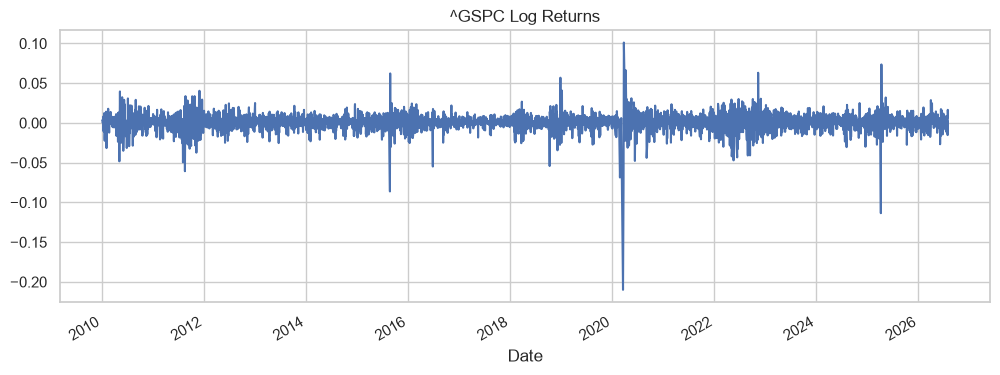

In [4]:
def calculate_returns(df, column='price'):
    df_ret = df.copy()
    df_ret['log_return'] = np.log(df_ret[column] / df_ret[column].shift(1))
    df_ret.dropna(inplace=True)
    return df_ret

df_returns = calculate_returns(df_clean)
df_returns['log_return'].plot(title=f'{ticker} Log Returns', figsize=(12, 4))
plt.show()

## 4. Modular VaR Models

In [5]:
def historical_var_model(returns, window=252, alpha=0.01):
    var_prediction = returns.rolling(window=window).quantile(alpha).shift(1)
    return var_prediction

def parametric_var_model(returns, window=252, alpha=0.01):
    rolling_mean = returns.rolling(window=window).mean()
    rolling_std = returns.rolling(window=window).std()
    z_score = norm.ppf(alpha)
    var_prediction = (rolling_mean + z_score * rolling_std).shift(1)
    return var_prediction

## 5. Statistical Requirements & Backtesting Window Size
When validating a VaR model, the amount of data (sample size $N$) is critical.

- **Regulatory Minimum (Basel):** Requires at least $N=250$ days of history (approx. 1 trading year). At 99% confidence ($lpha=0.01$), this means we theoretically expect only 2.5 breaches.
- **Statistical Power (Kupiec):** The Kupiec test has very low statistical power with small samples (it struggles to confidently reject bad models). To have a robust test for $lpha=0.01$, a window of **$N=500$ to $N=1000$ days** is highly recommended by literature, as this generates between 5 and 10 expected breaches.

To evaluate our models correctly, instead of running one global test, we will divide the out-of-sample data into **consecutive blocks (e.g., 252 days)** and test the model independently in each block.

## 6. The Likelihood Ratio (LR) Statistic
Instead of ranking models by their `p-value` (which can lose precision in the extremes), we rank them directly using the **Likelihood Ratio (LR) Statistic** from the Kupiec POF test. 

$$ LR = -2 \ln \left( 
rac{\alpha^x (1-\alpha)^{N-x}}{p^x (1-p)^{N-x}} 
ight) $$

Where:
- $N$ = total days in the window
- $x$ = observed breaches
- $p = x/N$ = empirical breach rate
- $\alpha$ = theoretical target (e.g., 0.01)

**IMPORTANT:** The LR statistic measures the "error" or distance between our empirical rate and the theoretical target. **A lower LR is better (0 is a perfect match)**.

In [6]:
def calc_kupiec_lr_statistic(x, N, alpha):
    """
    Calculates the Likelihood Ratio (LR) statistic for the Kupiec POF test.
    Lower LR indicates a better fit to the theoretical alpha (0 is perfect).
    """
    if N == 0:
        return np.nan
        
    p = x / N
    
    # Handle edge cases to avoid log(0)
    if x == 0:
        # If 0 breaches, the formula simplifies
        lr = -2 * np.log(((1 - alpha)**N) / ((1 - p)**N))
    elif x == N:
        lr = -2 * np.log((alpha**N) / (p**N))
    else:
        # Full LR formula
        numerator = (alpha**x) * ((1 - alpha)**(N - x))
        denominator = (p**x) * ((1 - p)**(N - x))
        lr = -2 * np.log(numerator / denominator)
        
    return lr

def evaluate_var_blocks(actual_returns, var_predictions, alpha, block_size=252):
    """
    Evaluates predictions in chunks (blocks) of size `block_size`.
    Returns a dataframe of results per block.
    """
    df_eval = pd.DataFrame({
        'Realized_Return': actual_returns,
        'Predicted_VaR': var_predictions
    }).dropna()
    
    df_eval['Breach'] = (df_eval['Realized_Return'] < df_eval['Predicted_VaR']).astype(int)
    
    # Split into blocks
    num_blocks = len(df_eval) // block_size
    
    block_stats = []
    
    for i in range(num_blocks):
        block_data = df_eval.iloc[i*block_size : (i+1)*block_size]
        total_days = len(block_data)
        breaches = block_data['Breach'].sum()
        
        lr_stat = calc_kupiec_lr_statistic(breaches, total_days, alpha)
        
        block_stats.append({
            'Block': i + 1,
            'Total Days': total_days,
            'Expected Breaches': round(total_days * alpha, 2),
            'Actual Breaches': breaches,
            'Breach Rate (%)': round((breaches / total_days) * 100, 2),
            'LR Statistic': lr_stat
        })
        
    return pd.DataFrame(block_stats), df_eval

## 7. Model and Parameter Comparison (Block Backtesting)

In [47]:
df_returns.iloc[end_window].name


Timestamp('2010-08-20 00:00:00')

In [92]:
block_size = 252
test_alpha = 0.01
func = historical_var_model
opt_window = 22 * 24
end_window = opt_window + 22

df_results = pd.DataFrame([])

while end_window < len(df_returns):
    max_rate = 1
    max_window = opt_window
    for i in [0, -1, 1]:
    
        aux_window = opt_window + 22 * i
        returns_series = df_returns.iloc[end_window - aux_window :end_window]['log_return']
        
        var_preds = float(np.quantile(returns_series, test_alpha))
        date = df_returns.iloc[end_window].name

        df_results.loc[date, 'log_return'] = df_returns.iloc[end_window]['log_return']
        df_results.loc[date, 'var'] = var_preds
        df_results.loc[date, 'breaches'] = 1 if df_results.loc[date, 'log_return'] < df_results.loc[date, 'var'] else 0
        rate = sum(df_results.loc[:date].tail(block_size)['breaches']) / len(df_results.loc[:date].tail(block_size)['breaches'])

        if np.abs(rate - test_alpha) < np.abs(max_rate - test_alpha):
            max_rate = rate
            max_window = aux_window
        df_results.loc[date, 'rate'] = max_rate
            
    df_results.loc[date, 'window'] = max_window
    
    opt_window = max_window
    end_window += 1
# df_results


<Axes: >

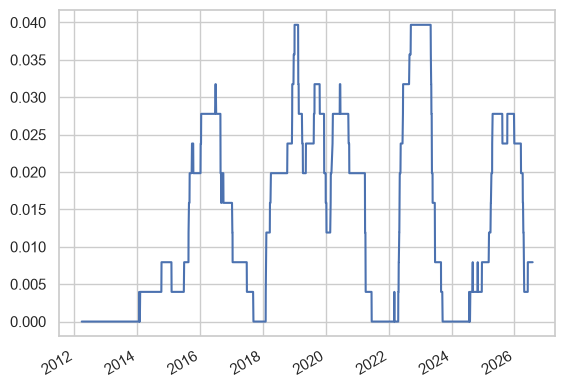

In [93]:
df_results.rate.plot()

<Axes: >

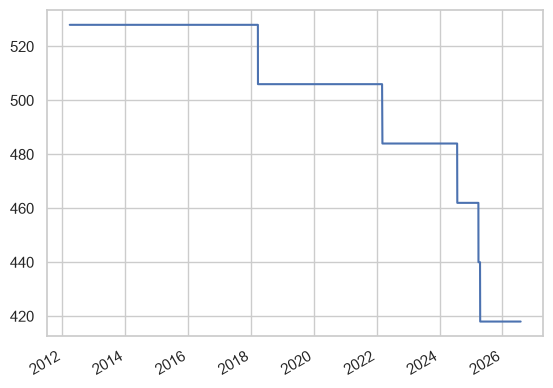

In [94]:
df_results.window.plot()

In [ ]:
window = 22 * 6
alpha = 0.01
func = historical_var_model

kwargs = {'window': window, 'alpha': alpha}
bt_window = 252
var_preds = func(df_returns['log_return'], **kwargs)
var_preds

Date
2010-01-06         NaN
2010-01-07         NaN
2010-01-08         NaN
2010-01-11         NaN
2010-01-12         NaN
                ...   
2026-07-27   -0.019825
2026-07-28   -0.019825
2026-07-29   -0.019825
2026-07-30   -0.019825
2026-07-31   -0.017344
Name: log_return, Length: 4107, dtype: float64

In [7]:
def run_model_comparison_blocked(returns_series, models_to_test, test_alpha=0.01, block_size=252):
    """
    Runs multiple models, tests them in blocks, and aggregates the LR statistic.
    Models are ranked by their average LR Statistic (Lower is better).
    Returns the summary table and a dataframe with granular block data.
    """
    summary_stats = []
    all_blocks_data = []
    
    for config in models_to_test:
        name = config['name']
        func = config['func']
        kwargs = config['kwargs']
        
        var_preds = func(returns_series, **kwargs)
        df_blocks, _ = evaluate_var_blocks(returns_series, var_preds, alpha=test_alpha, block_size=block_size)
        
        if df_blocks.empty:
            continue
            
        # Add model name to the block data
        df_blocks['Model Name'] = name
        all_blocks_data.append(df_blocks)
        
        # Aggregate the block results
        avg_lr = df_blocks['LR Statistic'].mean()
        max_lr = df_blocks['LR Statistic'].max()
        avg_breach_rate = df_blocks['Breach Rate (%)'].mean()
        total_breaches_all_blocks = df_blocks['Actual Breaches'].sum()
        total_days_all_blocks = df_blocks['Total Days'].sum()
        
        summary_stats.append({
            'Model Name': name,
            'Window': kwargs.get('window', 'N/A'),
            'Total Blocks ({}d)'.format(block_size): len(df_blocks),
            'Total Breaches': total_breaches_all_blocks,
            'Avg Breach Rate (%)': round(avg_breach_rate, 2),
            'Avg LR Statistic (Lower=Better)': round(avg_lr, 4),
            'Max LR (Worst Block)': round(max_lr, 4)
        })
        
    df_summary = pd.DataFrame(summary_stats)
    df_all_blocks = pd.concat(all_blocks_data, ignore_index=True) if all_blocks_data else pd.DataFrame()
    
    # Sort by Avg LR Statistic Ascending (Lowest error is ranked first)
    if not df_summary.empty:
        df_summary = df_summary.sort_values(by='Avg LR Statistic (Lower=Better)', ascending=True).reset_index(drop=True)
        
    return df_summary, df_all_blocks

# Define scenarios to test
models_to_test = [
    {'name': 'Hist_VaR_132d', 'func': historical_var_model, 'kwargs': {'window': 132, 'alpha': 0.01}},
    {'name': 'Hist_VaR_252d', 'func': historical_var_model, 'kwargs': {'window': 252, 'alpha': 0.01}},
    {'name': 'Hist_VaR_500d', 'func': historical_var_model, 'kwargs': {'window': 500, 'alpha': 0.01}},
    {'name': 'Param_VaR_132d', 'func': parametric_var_model, 'kwargs': {'window': 132, 'alpha': 0.01}},
    {'name': 'Param_VaR_252d', 'func': parametric_var_model, 'kwargs': {'window': 252, 'alpha': 0.01}},
    {'name': 'Param_VaR_500d', 'func': parametric_var_model, 'kwargs': {'window': 500, 'alpha': 0.01}},
]

summary_table, df_all_blocks = run_model_comparison_blocked(df_returns['log_return'], models_to_test, test_alpha=0.01, block_size=252)

In [8]:
from IPython.display import display

print("=== Model Comparison Summary (Block Testing Strategy) ===")
display(summary_table)

=== Model Comparison Summary (Block Testing Strategy) ===


,Model Name,Window,Total Blocks (252d),Total Breaches,Avg Breach Rate (%),Avg LR Statistic (Lower=Better),Max LR (Worst Block)
0,Hist_VaR_132d,132,15,66,1.75,2.3023,12.8331
1,Hist_VaR_252d,252,15,61,1.61,3.2697,10.1232
2,Hist_VaR_500d,500,14,46,1.30,4.2981,12.8331
3,Param_VaR_132d,132,15,92,2.43,6.1210,29.1887
4,Param_VaR_252d,252,15,95,2.51,8.2681,40.8011
5,Param_VaR_500d,500,14,74,2.10,8.9991,53.4951


## 8. Visualizing Block Performance
Here we plot how the models behave across different blocks (time regimes). We compare the number of breaches and the LR Statistic across time.

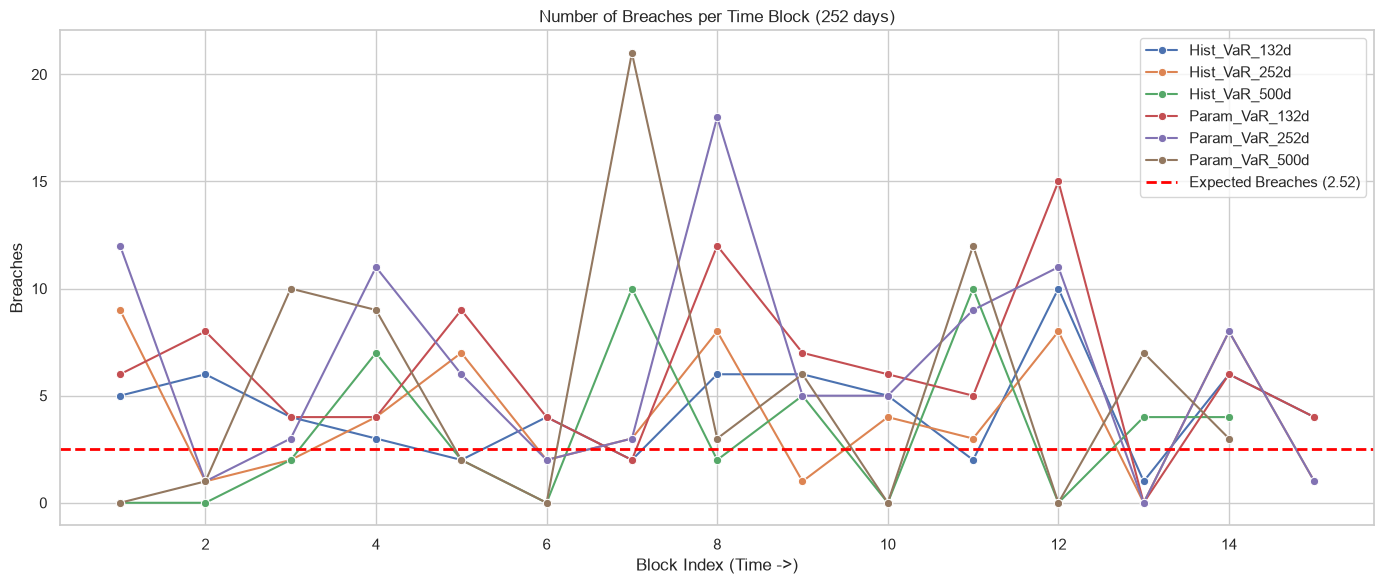

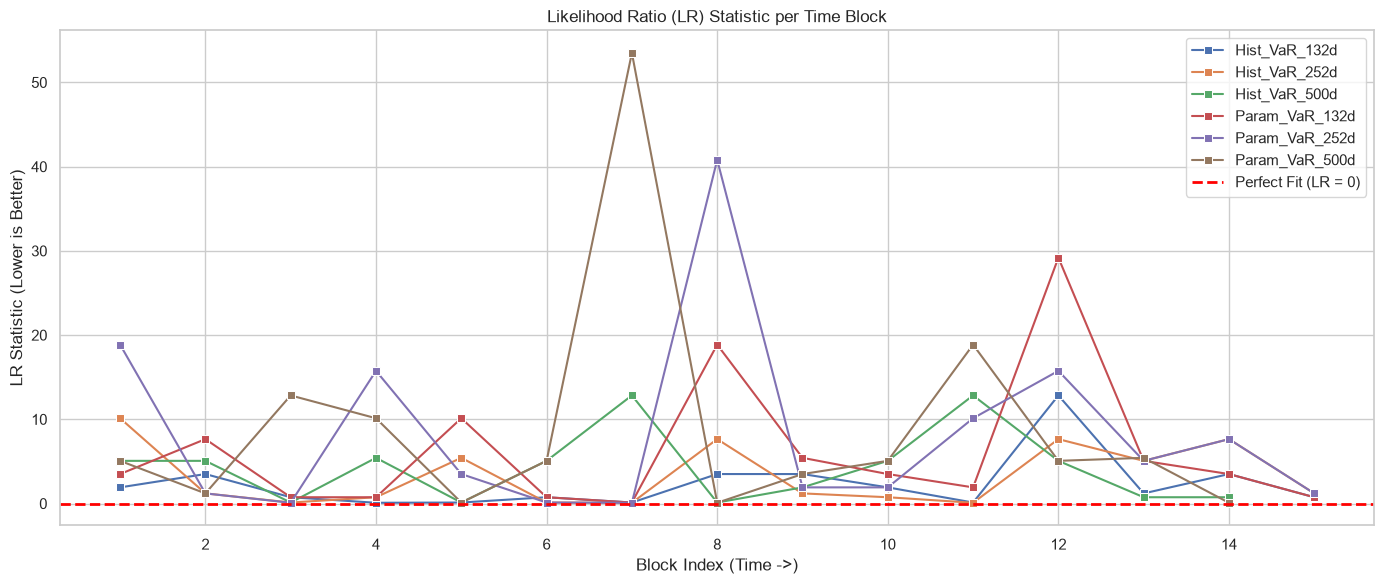

In [9]:
# 1. Breaches per Block Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_all_blocks, x='Block', y='Actual Breaches', hue='Model Name', marker='o')

# Add expected breaches line
expected_breaches = df_all_blocks['Expected Breaches'].iloc[0]
plt.axhline(y=expected_breaches, color='red', linestyle='--', linewidth=2, label=f'Expected Breaches ({expected_breaches})')

plt.title('Number of Breaches per Time Block (252 days)')
plt.ylabel('Breaches')
plt.xlabel('Block Index (Time ->)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. LR Statistic per Block Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_all_blocks, x='Block', y='LR Statistic', hue='Model Name', marker='s')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect Fit (LR = 0)')
plt.title('Likelihood Ratio (LR) Statistic per Time Block')
plt.ylabel('LR Statistic (Lower is Better)')
plt.xlabel('Block Index (Time ->)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Model Stability Analysis
A boxplot helps us understand the **variance** of the LR Statistic across all blocks. A model with a tight, low boxplot is consistently accurate across different market regimes, whereas a model with a very tall boxplot might be accurate on average but fails catastrophically during certain years.

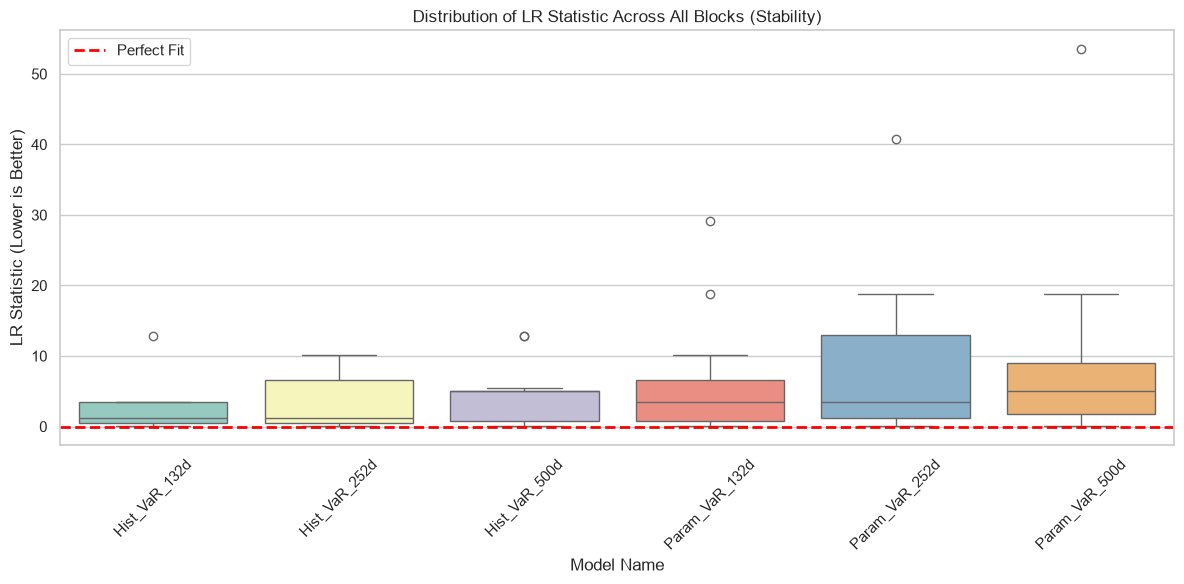

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_all_blocks, x='Model Name', y='LR Statistic', palette='Set3')
plt.title('Distribution of LR Statistic Across All Blocks (Stability)')
plt.ylabel('LR Statistic (Lower is Better)')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.legend()
plt.tight_layout()
plt.show()